QUANTUM CNN MODEL USING Adagrad OPTIMIZER

In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: # allow memory growth
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU config error:", e)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.optimizers import Adagrad
import pennylane as qml
import os
import time
import cv2
import csv

In [4]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# -------------------------
# Configuration (tweak these)
# -------------------------
IMG_SIZE = 64
BATCH_SIZE = 16
N_QUBITS = 4
N_LAYERS = 2
EPOCHS = 30
K_FOLDS = 5
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Quantum/noise/shots settings
SHOTS = 1000                # Number of circuit samples per forward pass (lower -> more statistical noise)
NOISE_PROB = 0.02           # Depolarizing noise probability (0.0 = no noise, 0.02 = 2% depolarizing)
USE_NOISE = True            # Toggle to enable/disable noise injection


print("="*70)
print("QUANTUM-INSPIRED CNN FOR BRAIN TUMOR CLASSIFICATION (UPDATED)")
print("="*70)
print(f"\nConfiguration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Quantum Qubits: {N_QUBITS}")
print(f"  Quantum Layers: {N_LAYERS}")
print(f"  K-Folds: {K_FOLDS}")
print(f"  Classes: {CLASS_NAMES}")
print(f"  Shots: {SHOTS}  (fewer shots => higher sampling noise)")
print(f"  Depolarizing Noise Enabled: {USE_NOISE}, Noise prob: {NOISE_PROB}")
print("="*70)

QUANTUM-INSPIRED CNN FOR BRAIN TUMOR CLASSIFICATION (UPDATED)

Configuration:
  Image Size: 64x64
  Quantum Qubits: 4
  Quantum Layers: 2
  K-Folds: 5
  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
  Shots: 1000  (fewer shots => higher sampling noise)
  Depolarizing Noise Enabled: True, Noise prob: 0.02


In [5]:
# -------------------------
# Quantum circuit (with noise)
# -------------------------
def quantum_circuit(inputs, weights):
    """Quantum circuit with data encoding, variational layers and optional depolarizing noise."""
    # Encode classical data into quantum states
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)

    # Optionally add depolarizing noise after encoding (simulates polarization/depolarizing noise)
    if USE_NOISE and NOISE_PROB > 0:
        for i in range(N_QUBITS):
            qml.DepolarizingChannel(NOISE_PROB, wires=i)

    # Variational quantum layers with entanglement
    for layer in range(N_LAYERS):
        # parameterized single-qubit rotations
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)

        # entangling CNOT chain
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])

        # Optionally add depolarizing noise between layers (models decoherence during circuit)
        if USE_NOISE and NOISE_PROB > 0:
            for i in range(N_QUBITS):
                qml.DepolarizingChannel(NOISE_PROB, wires=i)

    # Return expectation values (with finite shots these are estimated)
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


In [6]:
try:
    dev = qml.device("default.qubit", wires=N_QUBITS)
    qnode = qml.QNode(quantum_circuit, dev, interface='autograd')
    qnode = qml.transforms.set_shots(SHOTS)(qnode)
except Exception:
    # fallback for older versions
    dev = qml.device("default.qubit", wires=N_QUBITS, shots=SHOTS)
    qnode = qml.QNode(quantum_circuit, dev, interface='autograd')


/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/pennylane/devices/device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [7]:
# -------------------------
# Quantum-inspired Keras layer (classical differentiable approximation that can call qnode)
# -------------------------
class QuantumInspiredLayer(layers.Layer):
    def __init__(self, n_qubits, n_layers, **kwargs):
        super(QuantumInspiredLayer, self).__init__(**kwargs)
        self.n_qubits = n_qubits
        self.n_layers = n_layers

    def build(self, input_shape):
        self.rotation_weights = self.add_weight(
            name="rotation_weights",
            shape=(self.n_layers, self.n_qubits, 2),
            initializer=keras.initializers.RandomUniform(0, 2*np.pi),
            trainable=True
        )
        self.interaction_weights = self.add_weight(
            name="interaction_weights",
            shape=(self.n_layers, self.n_qubits, self.n_qubits),
            initializer=keras.initializers.GlorotUniform(),
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        """
        Primary forward pass — classical differentiable transformation inspired by quantum ops.
        Optionally demonstrates true quantum circuit outputs via qnode for small batches.
        """
        x = inputs
        for layer in range(self.n_layers):
            ry_transform = tf.cos(self.rotation_weights[layer, :, 0]) * x + \
                          tf.sin(self.rotation_weights[layer, :, 0]) * tf.roll(x, shift=1, axis=-1)

            rz_transform = tf.cos(self.rotation_weights[layer, :, 1]) * ry_transform - \
                          tf.sin(self.rotation_weights[layer, :, 1]) * tf.roll(ry_transform, shift=-1, axis=-1)

            interaction = tf.matmul(
                tf.expand_dims(rz_transform, axis=-1),
                tf.expand_dims(rz_transform, axis=-2)
            )

            interaction_effect = tf.reduce_sum(
                interaction * self.interaction_weights[layer],
                axis=-1
            )

            x = tf.tanh(rz_transform + 0.1 * interaction_effect)

        # x shape may be (batch, n_qubits) — keep as-is for downstream dense layer
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"n_qubits": self.n_qubits, "n_layers": self.n_layers})
        return config

    def demonstrate_quantum_circuit(self, sample_input):
        """
        Demonstrates the actual quantum circuit output for a small sample input using qnode.
        sample_input: 1D array-like length == n_qubits
        """
        try:
            weights_np = self.rotation_weights.numpy()
            # qnode uses SHOTS configured device and will return sampled expectation values
            result = qnode(sample_input, weights_np)
            return np.array(result)
        except Exception as e:
            print("Quantum demonstration failed:", str(e))
            return None

In [8]:
# -------------------------
# Model creation (uses QuantumInspiredLayer)
# -------------------------
def create_quantum_cnn_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Classical conv blocks
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),

        # Project to N_QUBITS for the quantum-inspired layer input
        layers.Dense(N_QUBITS, activation='tanh'),

        # Use the defined QuantumInspiredLayer
        QuantumInspiredLayer(N_QUBITS, N_LAYERS, name='quantum_layer'),

        # Output
        layers.Dense(len(CLASS_NAMES), activation='softmax')
    ])
    return model

In [9]:
# -------------------------
# Data loading
# -------------------------
def load_data(data_dir, img_size=IMG_SIZE):
    images = []
    labels = []
    for idx, class_name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: {class_dir} not found, skipping...")
            continue
        print(f"Loading {class_name}...", end=" ")
        count = 0
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (img_size, img_size))
                    img = img / 255.0
                    images.append(img)
                    labels.append(idx)
                    count += 1
            except Exception:
                continue
        print(f"{count} images loaded")
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

In [10]:
# -------------------------
# Grad-CAM and visual functions (unchanged)
# -------------------------
def create_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    if grads is None:
        return np.zeros((IMG_SIZE, IMG_SIZE))
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def visualize_gradcam(model, test_images, test_labels, save_path='gradcam_results.png'):
    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            last_conv_layer_name = layer.name
            break
    if last_conv_layer_name is None:
        print("No Conv2D layer found for Grad-CAM")
        return
    n_samples = min(8, len(test_images))
    indices = np.random.choice(len(test_images), n_samples, replace=False)
    fig, axes = plt.subplots(2, n_samples, figsize=(20, 5))
    if n_samples == 1:
        axes = axes.reshape(2, 1)
    for idx, img_idx in enumerate(indices):
        img = test_images[img_idx:img_idx+1]
        true_label = test_labels[img_idx]
        pred = model.predict(img, verbose=0)
        pred_label = np.argmax(pred[0])
        heatmap = create_gradcam_heatmap(model, img, last_conv_layer_name)
        heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
        axes[0, idx].imshow(img[0])
        axes[0, idx].set_title(f'True: {CLASS_NAMES[true_label]}', fontsize=8)
        axes[0, idx].axis('off')
        axes[1, idx].imshow(img[0])
        axes[1, idx].imshow(heatmap_resized, cmap='jet', alpha=0.5)
        axes[1, idx].set_title(f'Pred: {CLASS_NAMES[pred_label]}', fontsize=8)
        axes[1, idx].axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\nGrad-CAM visualization saved to {save_path}")
    plt.close()

In [11]:
def visualize_quantum_layer(model, test_images, save_path='quantum_layer_viz.png'):
    try:
        quantum_model = keras.Model(inputs=model.input, outputs=model.get_layer('quantum_layer').output)
    except Exception:
        print("Quantum layer not found for visualization")
        return
    n_samples = min(4, len(test_images))
    indices = np.random.choice(len(test_images), n_samples, replace=False)
    fig, axes = plt.subplots(n_samples, 2, figsize=(12, 3*n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, 2)
    for idx, img_idx in enumerate(indices):
        img = test_images[img_idx:img_idx+1]
        quantum_output = quantum_model.predict(img, verbose=0)[0]
        axes[idx, 0].imshow(img[0])
        axes[idx, 0].set_title('Input Image', fontsize=10)
        axes[idx, 0].axis('off')
        axes[idx, 1].bar(range(N_QUBITS), quantum_output)
        axes[idx, 1].set_title('Quantum Layer Activations', fontsize=10)
        axes[idx, 1].set_xlabel('Qubit')
        axes[idx, 1].set_ylabel('Activation')
        axes[idx, 1].set_ylim([-1, 1])
        axes[idx, 1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Quantum layer visualization saved to {save_path}")
    plt.close()

In [12]:
def plot_confusion_matrix(y_true, y_pred, save_path='confusion_matrix.png'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix - Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Confusion matrix saved to {save_path}")
    plt.close()

In [13]:
def plot_training_history(histories, save_path='training_history.png'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for fold_idx, history in enumerate(histories):
        axes[0].plot(history['accuracy'], label=f'Fold {fold_idx+1} Train', alpha=0.6)
        axes[0].plot(history['val_accuracy'], label=f'Fold {fold_idx+1} Val', alpha=0.6, linestyle='--')
    axes[0].set_title('Model Accuracy Across Folds')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    for fold_idx, history in enumerate(histories):
        axes[1].plot(history['loss'], label=f'Fold {fold_idx+1} Train', alpha=0.6)
        axes[1].plot(history['val_loss'], label=f'Fold {fold_idx+1} Val', alpha=0.6, linestyle='--')
    axes[1].set_title('Model Loss Across Folds')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Training history saved to {save_path}")
    plt.close()

In [14]:
class TimingCallback(Callback):
    def __init__(self, fold_no, epoch_time_records):
        super().__init__()
        self.fold_no = fold_no
        self.epoch_times = []
        self.epoch_time_records = epoch_time_records

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        t = time.time() - self._epoch_start
        self.epoch_times.append(t)
        # safely extract learning rate (Keras 3 uses .learning_rate)
        try:
            lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        except:
            lr = None
        # record: fold, epoch (1-based), time, train_acc, val_acc, train_loss, val_loss, lr
        train_acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        train_loss = logs.get('loss')
        val_loss = logs.get('val_loss')
        self.epoch_time_records.append([self.fold_no, epoch+1, t, train_acc, val_acc, train_loss, val_loss, lr])
        print(f"⏱️ [Fold {self.fold_no}] Epoch {epoch+1} time: {t:.2f}s | train_acc={train_acc:.4f} val_acc={val_acc:.4f}")


In [15]:
# -------------------------
# Main training/evaluation pipeline
# -------------------------
from tensorflow.keras.utils import to_categorical

def main():
    train_dir = 'Brain_Tumor_data/Training'
    test_dir = 'Brain_Tumor_data/Testing'

    if not os.path.exists(train_dir):
        print(f"\nError: Training directory '{train_dir}' not found!")
        return

    print("\n" + "="*70)
    print("LOADING DATA")
    print("="*70)
    X_train, y_train = load_data(train_dir)
    y_train = to_categorical(y_train, num_classes=len(CLASS_NAMES))

    print(f"\nTraining data: {X_train.shape}, Labels: {y_train.shape}")

    X_test, y_test = None, None
    if os.path.exists(test_dir):
        X_test, y_test = load_data(test_dir)
        if y_test is not None:
            y_test = to_categorical(y_test, num_classes=len(CLASS_NAMES))


        print(f"Testing data: {X_test.shape}, Labels: {y_test.shape}")
    else:
        print(f"\nWarning: Test directory '{test_dir}' not found. Skipping test evaluation.")

    # K-Fold Cross Validation
    print("\n" + "="*70)
    print("K-FOLD CROSS VALIDATION TRAINING")
    print("="*70)

    kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
    fold_scores = []
    histories = []
    best_model = None
    best_val_acc = 0.0
    epoch_time_records = []  # collect [fold, epoch, time, train_acc, val_acc, train_loss, val_loss, lr]
    os.makedirs("logs", exist_ok=True)

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
        fold_no = fold + 1
        print(f"\n{'='*70}")
        print(f"FOLD {fold_no}/{K_FOLDS}")
        print('='*70)

        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        print(f"Train samples: {len(X_fold_train)}, Val samples: {len(X_fold_val)}")

        model = create_quantum_cnn_model()
        # Compile with SGD(momentum=0.9)
        model.compile(
            optimizer=Adagrad(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        callbacks = [
            keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        ]

        timing_cb = TimingCallback(fold_no, epoch_time_records)
        callbacks.append(timing_cb)

        fold_start_time = time.time()
        try:
            history = model.fit(
                X_fold_train, y_fold_train,
                validation_data=(X_fold_val, y_fold_val),
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                callbacks=callbacks,
                verbose=1
            )
            fold_training_time = time.time() - fold_start_time

            val_loss, val_acc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
            fold_scores.append(val_acc)
            histories.append(history.history)

            print(f"\nFold {fold_no} Results:")
            print(f"  Validation Accuracy: {val_acc:.4f}")
            print(f"  Validation Loss: {val_loss:.4f}")
            print(f"  Fold Training Time: {fold_training_time:.2f} seconds")

            # Save model for this fold
            model.save(f"quantum_cnn_fold{fold_no}.keras")
            print(f"[INFO] Saved fold model: quantum_cnn_fold{fold_no}.keras")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                print(f"  *** New best model! ***")

        except Exception as e:
            print(f"\nError in fold {fold_no}: {str(e)}")
            continue

    if len(fold_scores) == 0:
        print("\nNo folds completed successfully.")
        return

    # Save epoch timing CSV
    csv_path = "logs/qcnn_epoch_times.csv"
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Fold", "Epoch", "TimeSec", "TrainAcc", "ValAcc", "TrainLoss", "ValLoss", "LR"])
        writer.writerows(epoch_time_records)
    print(f"[INFO] Epoch timing data saved to: {csv_path}")

    # Plot epoch times
    if len(epoch_time_records) > 0:
        arr = np.array(epoch_time_records)
        folds_plot = arr[:,0].astype(int)
        epochs_plot = arr[:,1].astype(int)
        times_plot = arr[:,2].astype(float)

        plt.figure(figsize=(10,6))
        sns.lineplot(x=epochs_plot, y=times_plot, hue=folds_plot, marker="o")
        plt.title("Training Time per Epoch across Folds")
        plt.xlabel("Epoch")
        plt.ylabel("Time (seconds)")
        plt.legend(title="Fold", loc="upper left")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plot_path = "logs/qcnn_epoch_time_plot.png"
        plt.savefig(plot_path)
        plt.show()
        plt.close()
        print(f"[INFO] Epoch time plot saved to: {plot_path}")

    # CV summary
    print("\n" + "="*70)
    print("CROSS-VALIDATION RESULTS")
    print("="*70)
    print(f"Fold Accuracies: {[f'{acc:.4f}' for acc in fold_scores]}")
    print(f"Mean CV Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
    print(f"Best Fold Accuracy: {max(fold_scores):.4f}")

    # Plot training history
    if len(histories) > 0:
        plot_training_history(histories)

    # Test evaluation using best_model
    if X_test is not None and y_test is not None and best_model is not None:
        print("\n" + "="*70)
        print("TEST SET EVALUATION")
        print("="*70)
        test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")

        y_pred = best_model.predict(X_test, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_test, axis=1)

        # Classification report & metrics
        print("\n" + "-"*70)
        print("CLASSIFICATION REPORT")
        print("-"*70)
        print(classification_report(y_true_classes, y_pred_classes, target_names=CLASS_NAMES))
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average=None, labels=range(len(CLASS_NAMES))
        )
        print("\n" + "-"*70)
        print("PER-CLASS PERFORMANCE ANALYSIS")
        print("-"*70)
        for i, class_name in enumerate(CLASS_NAMES):
            print(f"\n{class_name.upper()}:")
            print(f"  Precision: {precision[i]:.4f}")
            print(f"  Recall:    {recall[i]:.4f}")
            print(f"  F1-Score:  {f1[i]:.4f}")
            print(f"  Support:   {support[i]}")

        # Visualizations
        plot_confusion_matrix(y_true_classes, y_pred_classes)
        # visualize_gradcam(best_model, X_test, y_test)
        visualize_quantum_layer(best_model, X_test)

    # Save best model
    if best_model is not None:
        best_model.save('quantum_cnn_brain_tumor_model.keras')
        print("\n" + "="*70)
        print("Model saved as 'quantum_cnn_brain_tumor_model.keras'")
        print("="*70)

    print("\n✓ Training and evaluation complete!")
    print("\nGenerated files:")
    print("  1. quantum_cnn_brain_tumor_model.keras - Trained best model")
    print("  2. quantum_cnn_fold{n}.keras - Per-fold saved models")
    print("  3. logs/qcnn_epoch_times.csv - Epoch timing & metrics")
    print("  4. logs/qcnn_epoch_time_plot.png - Epoch time plot")
    print("  5. training_history.png - Training curves")
    print("  6. confusion_matrix.png - Confusion matrix")
    print("  7. gradcam_results.png - Grad-CAM visualizations")
    print("  8. quantum_layer_viz.png - Quantum layer activations")


LOADING DATA
Loading glioma... 1321 images loaded
Loading meningioma... 1339 images loaded
Loading notumor... 1595 images loaded
Loading pituitary... 1457 images loaded

Training data: (5712, 64, 64, 3), Labels: (5712, 4)
Loading glioma... 300 images loaded
Loading meningioma... 306 images loaded
Loading notumor... 405 images loaded
Loading pituitary... 300 images loaded
Testing data: (1311, 64, 64, 3), Labels: (1311, 4)

K-FOLD CROSS VALIDATION TRAINING

FOLD 1/5
Train samples: 4569, Val samples: 1143


I0000 00:00:1761947010.178400   12440 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/30


2025-10-31 21:43:38.527974: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f5838007f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-31 21:43:38.528027: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-10-31 21:43:39.050074: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-31 21:43:40.109215: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300


  1/286 ━━━━━━━━━━━━━━━━━━━━ 1:32:04 19s/step - accuracy: 0.1875 - loss: 1.4771

...

286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3876 - loss: 1.2676⏱️ [Fold 1] Epoch 1 time: 38.10s | train_acc=0.4511 val_acc=0.3640
286/286 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - accuracy: 0.4511 - loss: 1.2095 - val_accuracy: 0.3640 - val_loss: 1.2996 - learning_rate: 0.0010
Epoch 2/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5477 - loss: 1.1331⏱️ [Fold 1] Epoch 2 time: 4.08s | train_acc=0.5559 val_acc=0.5144
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5559 - loss: 1.1225 - val_accuracy: 0.5144 - val_loss: 1.1219 - learning_rate: 0.0010
Epoch 3/30
282/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5861 - loss: 1.1029⏱️ [Fold 1] Epoch 3 time: 4.05s | train_acc=0.6014 val_acc=0.6238
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6014 - loss: 1.0891 - val_accuracy: 0.6238 - val_loss: 1.0530 - learning_rate: 0.0010
Epoch 4/30
282/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6163 - loss: 1.0758⏱️ [Fold 1] Epoch 4 time: 4.06s | train_a

2025-10-31 21:46:16.640880: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_288', 8 bytes spill stores, 8 bytes spill loads




Fold 1 Results:
  Validation Accuracy: 0.8224
  Validation Loss: 0.8260
  Fold Training Time: 158.83 seconds
[INFO] Saved fold model: quantum_cnn_fold1.keras
  *** New best model! ***

FOLD 2/5
Train samples: 4569, Val samples: 1143
Epoch 1/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3475 - loss: 1.3215⏱️ [Fold 2] Epoch 1 time: 25.58s | train_acc=0.3946 val_acc=0.4112
286/286 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.3946 - loss: 1.2481 - val_accuracy: 0.4112 - val_loss: 1.2564 - learning_rate: 0.0010
Epoch 2/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4347 - loss: 1.1450⏱️ [Fold 2] Epoch 2 time: 4.11s | train_acc=0.4445 val_acc=0.4619
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4445 - loss: 1.1356 - val_accuracy: 0.4619 - val_loss: 1.1340 - learning_rate: 0.0010
Epoch 3/30
282/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5477 - loss: 1.1131⏱️ [Fold 2] Epoch 3 time: 4.01s | train_acc=0.5699 val_acc=0.5669
286/286 ━━━━━━━━━━━━━━━━

2025-10-31 21:51:19.595902: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_288', 8 bytes spill stores, 8 bytes spill loads




Fold 3 Results:
  Validation Accuracy: 0.8039
  Validation Loss: 0.8423
  Fold Training Time: 145.71 seconds
[INFO] Saved fold model: quantum_cnn_fold3.keras

FOLD 4/5
Train samples: 4570, Val samples: 1142
Epoch 1/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3740 - loss: 1.3911⏱️ [Fold 4] Epoch 1 time: 21.52s | train_acc=0.4260 val_acc=0.2478
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.4260 - loss: 1.3526 - val_accuracy: 0.2478 - val_loss: 1.4210 - learning_rate: 0.0010
Epoch 2/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5009 - loss: 1.2801⏱️ [Fold 4] Epoch 2 time: 4.10s | train_acc=0.5256 val_acc=0.3722
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5256 - loss: 1.2607 - val_accuracy: 0.3722 - val_loss: 1.3401 - learning_rate: 0.0010
Epoch 3/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5556 - loss: 1.2270⏱️ [Fold 4] Epoch 3 time: 4.18s | train_acc=0.5600 val_acc=0.5429
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accura

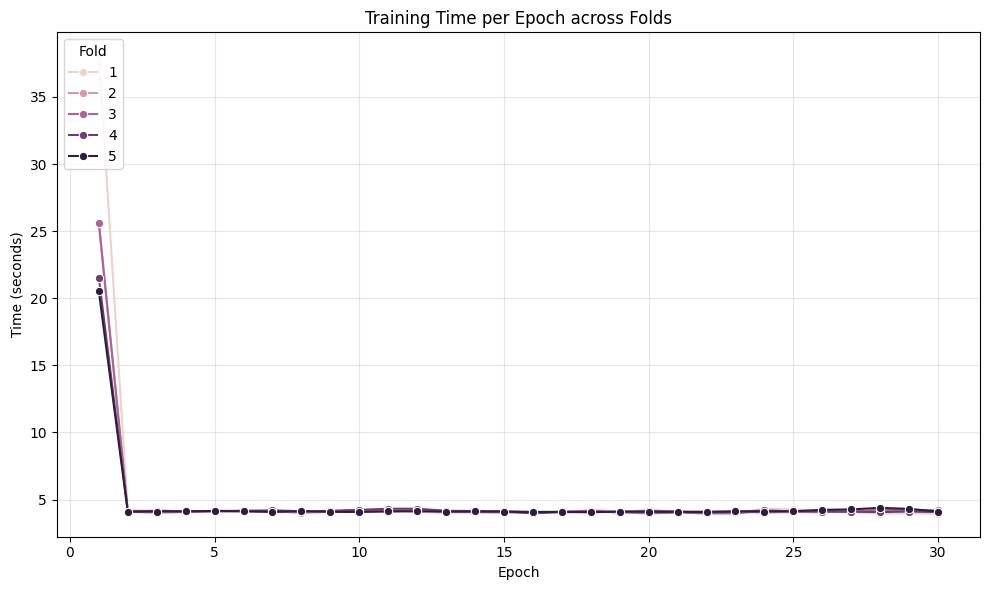

[INFO] Epoch time plot saved to: logs/qcnn_epoch_time_plot.png

CROSS-VALIDATION RESULTS
Fold Accuracies: ['0.8224', '0.7472', '0.8039', '0.6637', '0.6629']
Mean CV Accuracy: 0.7400 (+/- 0.0674)
Best Fold Accuracy: 0.8224
Training history saved to training_history.png

TEST SET EVALUATION


2025-10-31 21:56:16.370282: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_288', 8 bytes spill stores, 8 bytes spill loads



Test Accuracy: 0.7445
Test Loss: 0.9242

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

      glioma       0.72      0.83      0.77       300
  meningioma       0.64      0.31      0.42       306
     notumor       0.82      0.83      0.82       405
   pituitary       0.73      0.98      0.83       300

    accuracy                           0.74      1311
   macro avg       0.73      0.74      0.71      1311
weighted avg       0.73      0.74      0.72      1311


----------------------------------------------------------------------
PER-CLASS PERFORMANCE ANALYSIS
----------------------------------------------------------------------

GLIOMA:
  Precision: 0.7205
  Recall:    0.8333
  F1-Score:  0.7728
  Support:   300

MENINGIOMA:
  Precision: 0.6443
  Recall:    0.3137
  F1-Score:  0.4220
  Support:   306

NOTUMOR:


In [16]:
if __name__ == "__main__":
    main()


In [17]:
from tensorflow.keras.models import load_model

model=load_model("quantum_cnn_brain_tumor_model.keras",  custom_objects={"QuantumInspiredLayer": QuantumInspiredLayer})
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           26

 Total params: 1,626,066 (6.20 MB)

 Trainable params: 812,584 (3.10 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 812,586 (3.10 MB)

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load log data
df = pd.read_csv("logs/qcnn_epoch_times.csv")
df.head()


,Fold,Epoch,TimeSec,TrainAcc,ValAcc,TrainLoss,ValLoss,LR
0,1,1,38.100341,0.451083,0.363955,1.209512,1.299650,0.001
1,1,2,4.081012,0.555920,0.514436,1.122454,1.121888,0.001
2,1,3,4.049402,0.601445,0.623797,1.089140,1.053026,0.001
3,1,4,4.056108,0.629678,0.665792,1.067866,1.023460,0.001
4,1,5,4.138494,0.661414,0.671041,1.039696,1.015660,0.001


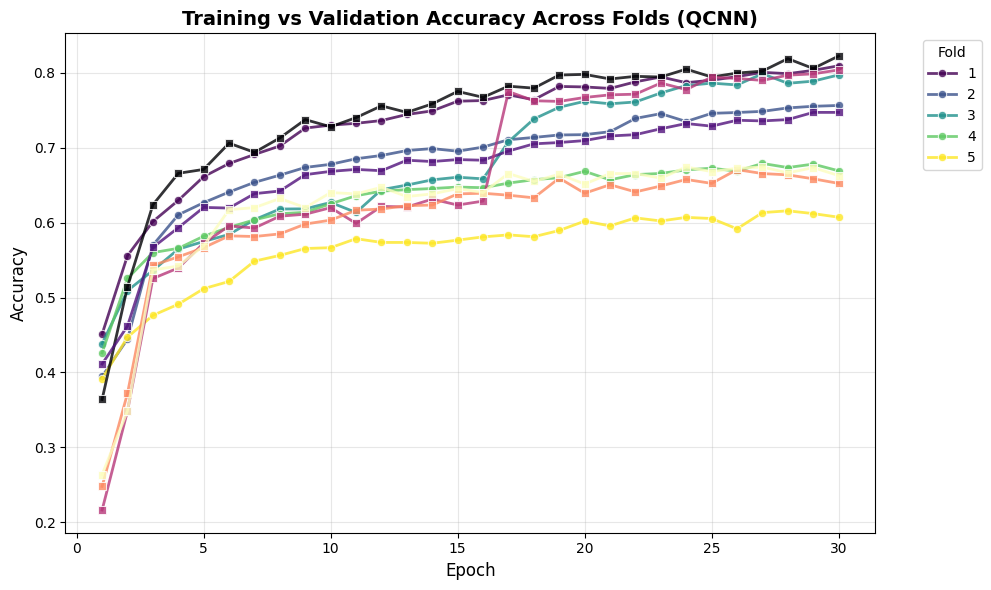

In [19]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df, 
    x='Epoch', y='TrainAcc', 
    hue='Fold', 
    marker='o', 
    palette='viridis', 
    alpha=0.8, 
    linewidth=2
)
sns.lineplot(
    data=df, 
    x='Epoch', y='ValAcc', 
    hue='Fold', 
    marker='s', 
    palette='magma', 
    alpha=0.8, 
    linewidth=2,
    legend=False
)

plt.title("Training vs Validation Accuracy Across Folds (QCNN)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(title='Fold', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


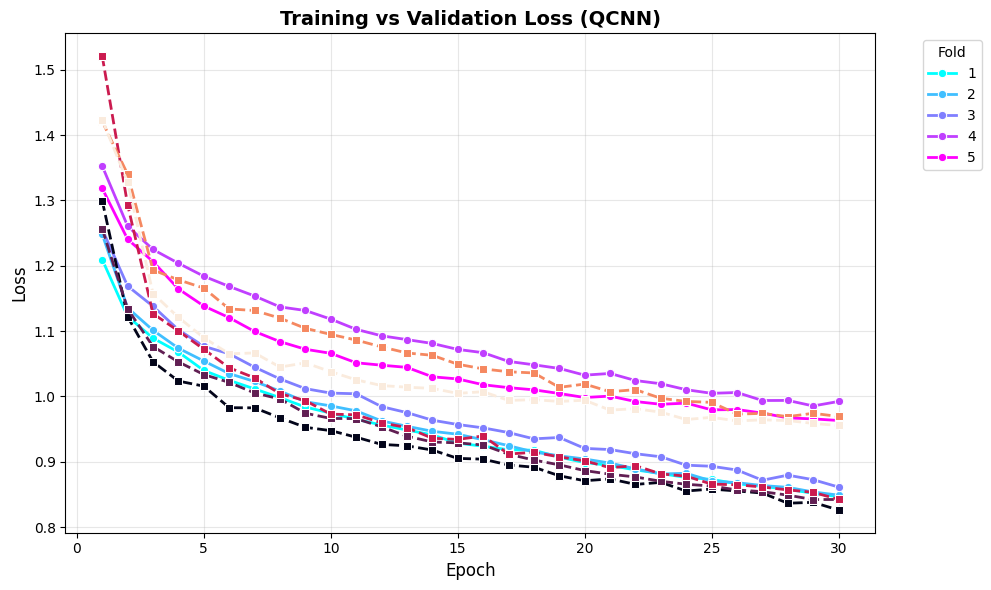

In [20]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Epoch', y='TrainLoss', hue='Fold', palette='cool', linewidth=2, marker='o')
sns.lineplot(data=df, x='Epoch', y='ValLoss', hue='Fold', palette='rocket', linewidth=2, linestyle='--', marker='s', legend=False)

plt.title("Training vs Validation Loss (QCNN)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(title='Fold', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


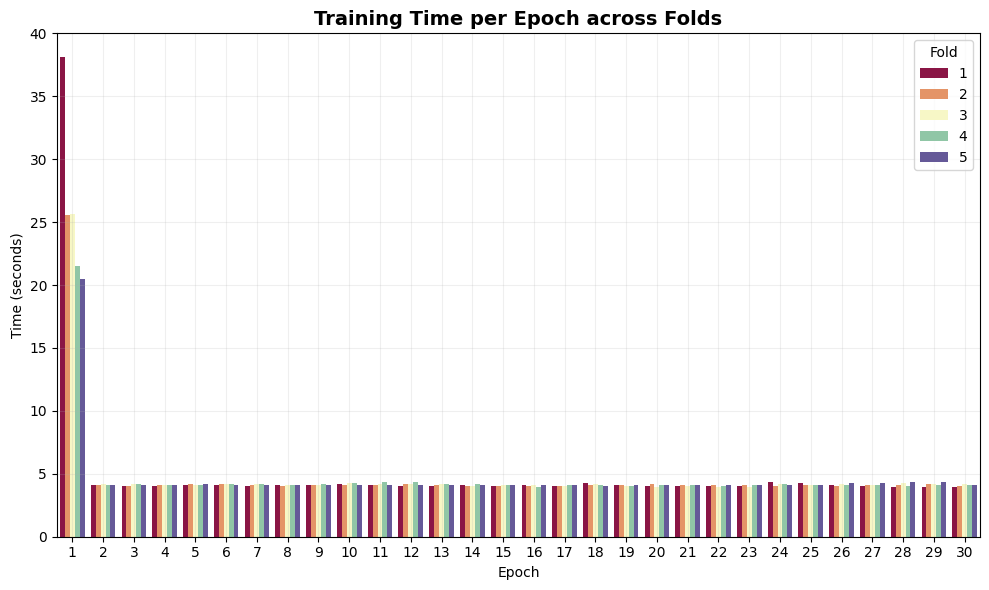

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Epoch', y='TimeSec', hue='Fold', palette='Spectral')
plt.title("Training Time per Epoch across Folds", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [22]:
fig = px.line(
    df, 
    x='Epoch', 
    y=['TrainAcc', 'ValAcc'], 
    color_discrete_sequence=['#1f77b4', '#ff7f0e'],
    title='QCNN Training and Validation Accuracy (Interactive)',
    markers=True
)
fig.update_layout(
    template='plotly_dark',
    xaxis_title='Epoch',
    yaxis_title='Accuracy',
    legend_title_text='Metric',
    font=dict(size=12)
)
fig.show()


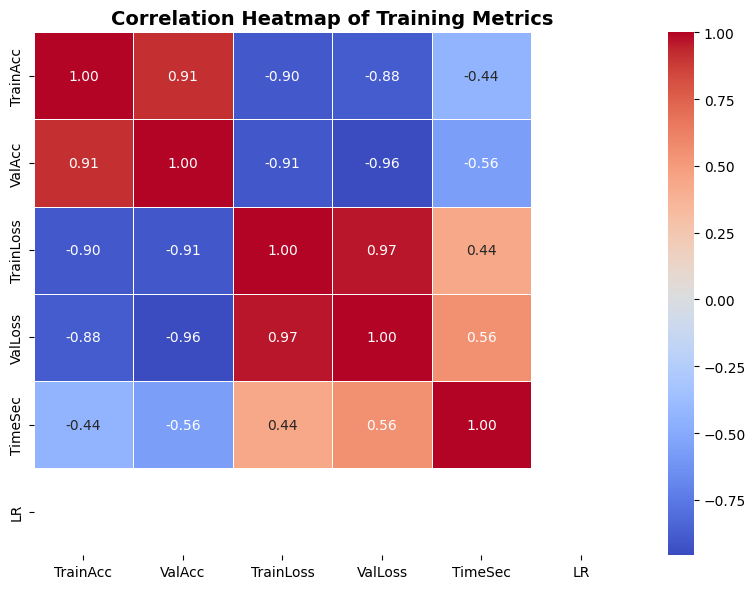

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['TrainAcc','ValAcc','TrainLoss','ValLoss','TimeSec','LR']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Training Metrics", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [24]:
summary = df.groupby('Fold')[['TrainAcc','ValAcc','TrainLoss','ValLoss','TimeSec']].agg(['mean','max','min'])
display(summary)


TrainAcc                      ...   TimeSec                     
          mean       max       min  ...      mean        max       min
Fold                                ...                               
1     0.731954  0.809367  0.451083  ...  5.220106  38.100341  3.944284
2     0.680922  0.756402  0.394616  ...  4.812751  25.581825  4.012851
3     0.677899  0.798687  0.438293  ...  4.845261  25.617310  3.969090
4     0.630190  0.678993  0.426039  ...  4.713348  21.516319  3.972078
5     0.564807  0.615755  0.391466  ...  4.679339  20.511084  4.057735

[5 rows x 15 columns]